# Why Do We Need Embeddings and Self-Attention in a Transformer?

The basic idea is:

**Words → Embeddings → Positional Information → Self-Attention →
Context-aware representations → Prediction**

For example:

``` text
"Nitish killed the lion"
```

Each word/token is first converted into a numerical vector and then
passed through the Transformer.

------------------------------------------------------------------------

## 1. Why can't we directly give words to the Transformer?

A neural network works with numbers, not words.

For example:

``` text
"Nitish"
"killed"
"the"
"lion"
```

cannot directly be used for matrix multiplication.

Therefore, each word/token is converted into a vector:

``` text
"Nitish" → [0.12, -0.43, 0.81, ...]
"killed" → [0.52,  0.17, -0.31, ...]
"the"    → [0.01, -0.12, 0.42, ...]
"lion"   → [0.73,  0.51, -0.21, ...]
```

This vector is called an **embedding**.

------------------------------------------------------------------------

## 2. Why do we need an embedding dimension?

Suppose we choose:

``` text
Embedding dimension = 512
```

Then every token is represented by a vector containing 512 numbers.

For our sentence:

``` text
Nitish   → 512 numbers
killed   → 512 numbers
the      → 512 numbers
lion     → 512 numbers
```

Therefore, if there are 4 tokens:

``` text
Input shape = (4, 512)
```

The `512` is the **embedding dimension**.

### Why 512?

There is nothing magical about 512. It is a **hyperparameter** chosen by
the model designer.

For example, we could use:

``` text
128
256
512
768
1024
```

A larger dimension gives the model more capacity to represent
information, but also increases parameters, memory usage, and
computation.

------------------------------------------------------------------------

## 3. What is the vocabulary?

The model cannot have a completely new output neuron for every possible
string.

Instead, we create a vocabulary.

For example:

``` text
Vocabulary:

0 → the
1 → cat
2 → dog
3 → lion
4 → killed
5 → ran
...
```

Suppose:

``` text
Vocabulary size = 10,000
```

Then the model has 10,000 possible tokens that it can predict.

------------------------------------------------------------------------

## 4. Embedding Matrix

If:

``` text
Vocabulary size = 10,000
Embedding dimension = 512
```

then the embedding table is:

``` text
10,000 × 512
```

Each row corresponds to one token.

When the token `"lion"` is encountered, its token ID is used to select
the corresponding row from this matrix.

------------------------------------------------------------------------

## 5. Why do we need Self-Attention?

This is the most important part.

Consider:

``` text
"The lion killed the man"
```

When the model processes `"lion"`, it should understand that `"lion"` is
related to `"killed"` and also potentially `"man"` because those words
provide context.

The meaning of a word depends heavily on the surrounding words.

This is why we need **Self-Attention**.

------------------------------------------------------------------------

## 6. What does Self-Attention do?

Self-attention allows each token to look at other tokens in the sequence
and determine:

> "Which other tokens are important for understanding me?"

For example:

``` text
Nitish   killed   the   lion
   ↑       ↑       ↑      ↑
   └───────┴───────┴──────┘
          Attention
```

The representation of `"killed"` can attend to `"Nitish"` and `"lion"`
because those words provide important context.

------------------------------------------------------------------------

## 7. Why is Self-Attention necessary?

Suppose we have:

``` text
"The bank is near the river."
```

Here `"bank"` means a river bank.

But:

``` text
"I deposited money in the bank."
```

Here `"bank"` means a financial institution.

The word itself is the same, but its meaning changes depending on the
surrounding words.

Self-attention allows the model to incorporate this surrounding context.

Therefore:

``` text
Embedding
    ↓
initial token representation
    ↓
Self-Attention
    ↓
context-aware representation
```

------------------------------------------------------------------------

## 8. Embedding vs Self-Attention

### Embedding

Answers:

> "What is this token?"

For example:

``` text
lion → vector
```

### Self-Attention

Answers:

> "What does this token mean in the context of the other tokens?"

For example:

``` text
lion
 ↓
looks at surrounding tokens
 ↓
gets contextual representation
```

So the embedding is relatively **token-specific**, while the
representation after attention becomes **context-dependent**.

------------------------------------------------------------------------

## 9. Why do we need positional information?

Consider:

``` text
Dog bites man
```

and:

``` text
Man bites dog
```

The same words are present, but the meaning is completely different.

A Transformer therefore needs information about **where a token occurs
in the sequence**.

For example:

``` text
Dog   → position 0
bites → position 1
man   → position 2
```

The model combines token information with positional information.

Conceptually:

``` text
Token Embedding
       +
Position Information
       ↓
Transformer Input
```

This allows the model to distinguish the two sentences.

------------------------------------------------------------------------

## 10. Why does the diagram show "0--1"?

For sinusoidal positional encoding, values are based on sine and cosine
functions, whose outputs lie between:

``` text
-1 and +1
```

The important idea is that every position gets a different numerical
pattern.

For example:

``` text
Position 0 → [pattern 0]
Position 1 → [pattern 1]
Position 2 → [pattern 2]
Position 3 → [pattern 3]
```

So the model can distinguish positions.

------------------------------------------------------------------------

## 11. What happens after Self-Attention?

After self-attention, every token has a new representation containing
contextual information.

For example:

``` text
Input:

Nitish
killed
the
lion

       ↓

Self-Attention

       ↓

Context-aware representations:

Nitish'
killed'
the'
lion'
```

The prime (`'`) means that the representation now contains information
obtained from surrounding tokens.

------------------------------------------------------------------------

## 12. How does the model predict the next word?

Suppose the input is:

``` text
"Nitish killed the"
```

The model might need to predict:

``` text
lion
```

The final representation is passed through a neural network that
produces **logits**.

If:

``` text
Vocabulary size = 10,000
```

then the output contains:

``` text
10,000 logits
```

Conceptually:

``` text
Transformer output
        ↓
Linear layer
        ↓
10,000 logits
        ↓
Softmax
        ↓
10,000 probabilities
```

For example:

``` text
lion    → 0.62
tiger   → 0.10
dog     → 0.05
car     → 0.001
...
```

The model uses these probabilities to predict the next token.

------------------------------------------------------------------------

## 13. Why is the final output size equal to vocabulary size?

Because the model needs to answer:

> "Which token from my vocabulary should come next?"

If the vocabulary contains 10,000 tokens, there are 10,000 possible
answers.

Therefore:

``` text
Output dimension = Vocabulary size
```

------------------------------------------------------------------------

## 14. Why does the output layer have so many parameters?

Suppose:

``` text
Hidden dimension = 512
Vocabulary size = 10,000
```

Then the final linear layer approximately contains:

``` text
512 × 10,000 = 5,120,000 weights
```

plus approximately 10,000 bias parameters.

So:

``` text
Total ≈ 5.13 million parameters
```

This is why vocabulary size has a major effect on the size of a language
model.

------------------------------------------------------------------------

## 15. Complete Flow

``` text
                 Sentence
                    │
                    ▼
              Tokenization
                    │
                    ▼
               Token IDs
                    │
                    ▼
            Token Embeddings
                    │
                    ▼
          Add Positional Information
                    │
                    ▼
              Self-Attention
                    │
                    ▼
          Contextual Representations
                    │
                    ▼
             Linear Projection
                    │
                    ▼
                  Logits
                    │
                    ▼
                Softmax
                    │
                    ▼
             Token Probabilities
                    │
                    ▼
             Predicted Token
```

------------------------------------------------------------------------

## 16. Main Reason for Every Component

  -----------------------------------------------------------------------
  Component                           Why do we need it?
  ----------------------------------- -----------------------------------
  Tokenizer                           Converts text into token IDs

  Embedding                           Converts token IDs into vectors

  Positional information              Tells the model where each token
                                      occurs

  Self-Attention                      Allows tokens to use information
                                      from other tokens

  Transformer layers                  Repeatedly build richer contextual
                                      representations

  Linear layer                        Converts the hidden representation
                                      into vocabulary-sized logits

  Softmax                             Converts logits into probabilities

  Vocabulary                          Defines the possible tokens that
                                      can be predicted
  -----------------------------------------------------------------------

------------------------------------------------------------------------

## 17. One-Line Intuition

> **Embedding tells the Transformer what a token is, positional
> information tells it where the token is, and self-attention tells it
> how that token relates to the other tokens.**

Then the final layer asks:

> **"Given all this context, which token should I predict next?"**


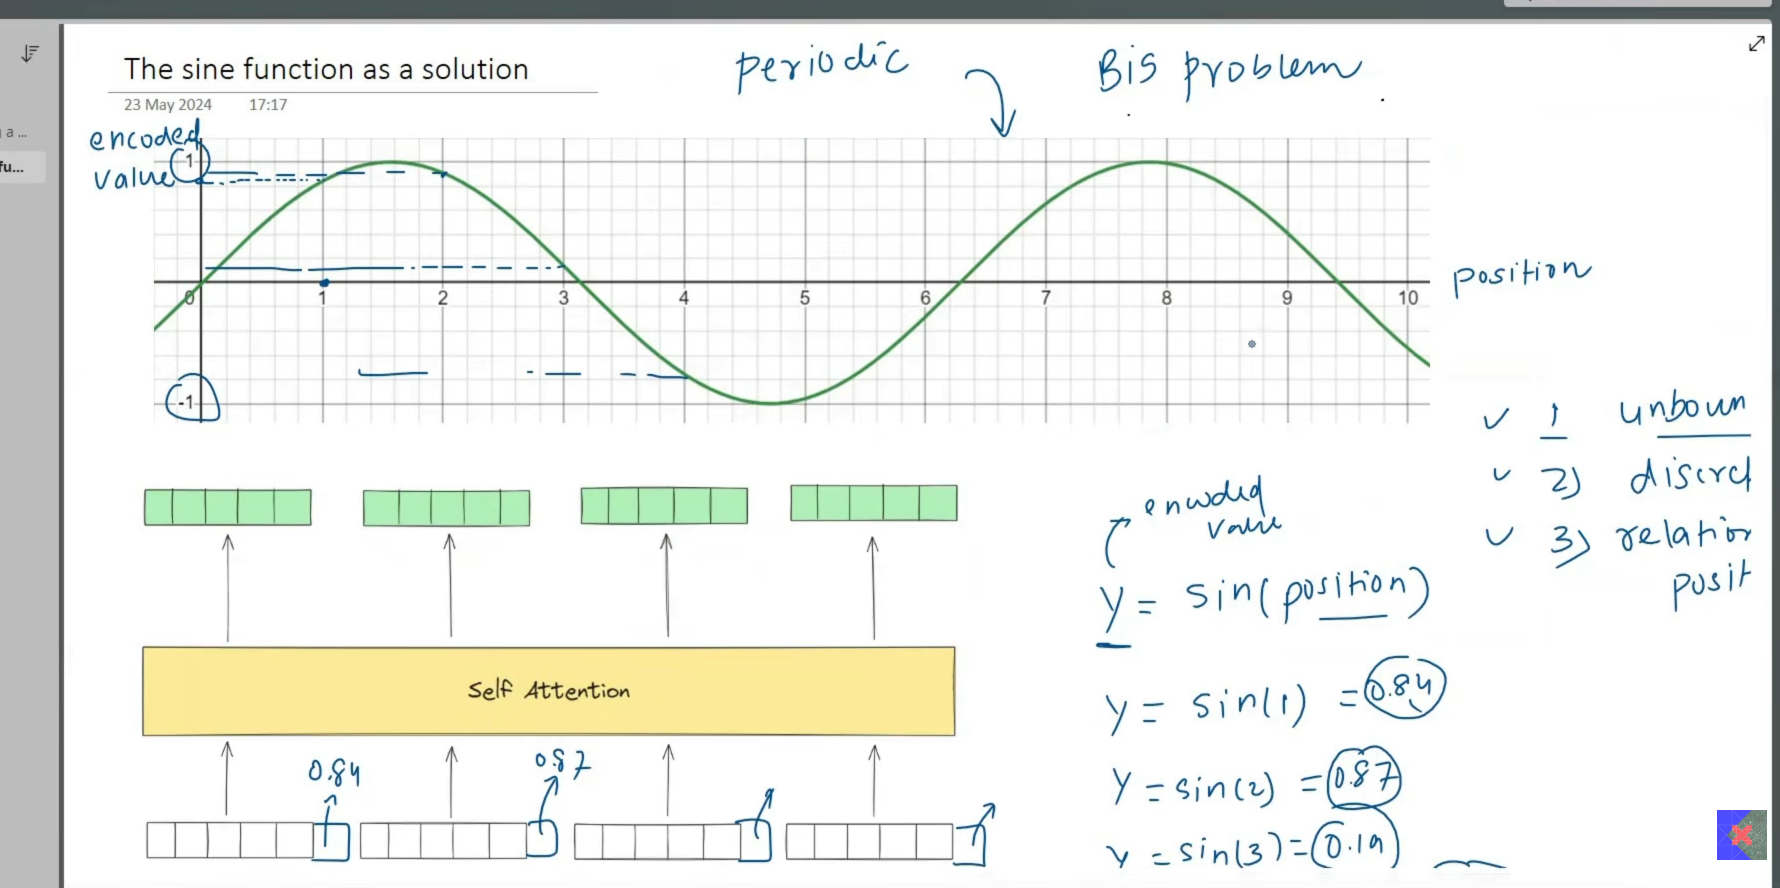

## This was fine that it has the bounded valeus and it holds the relational positiong then the other issue is that it has it has since it is a continious function then the values may repeat

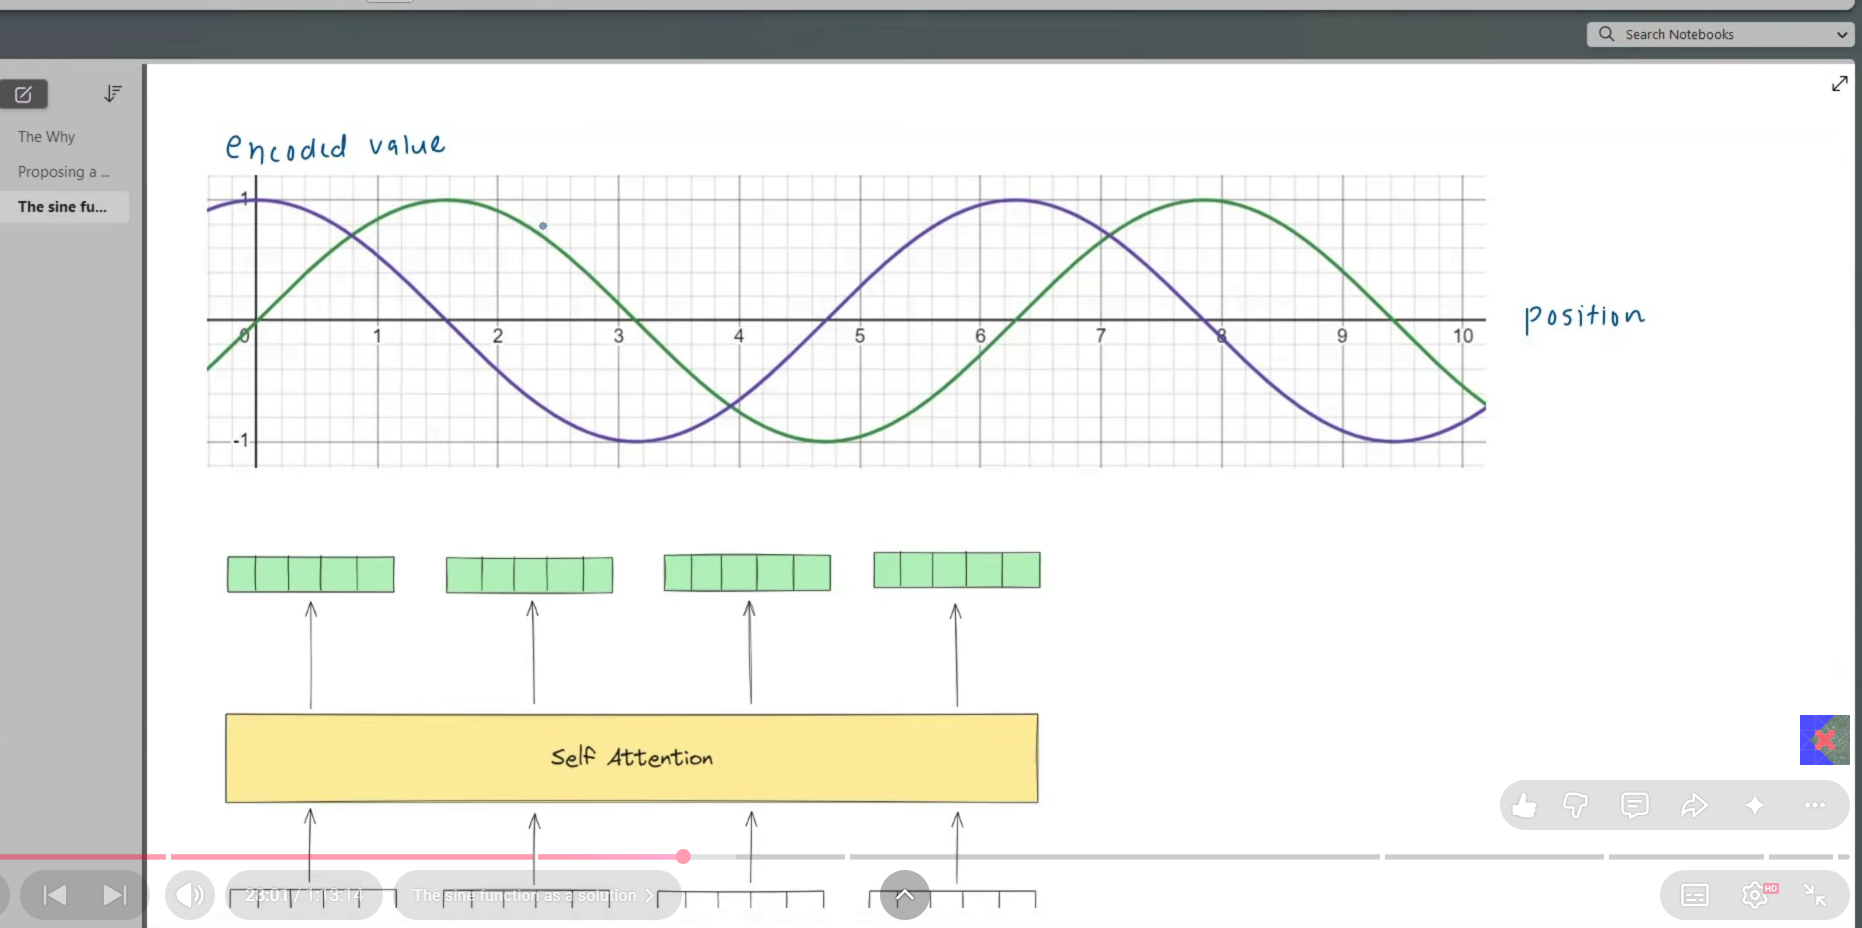

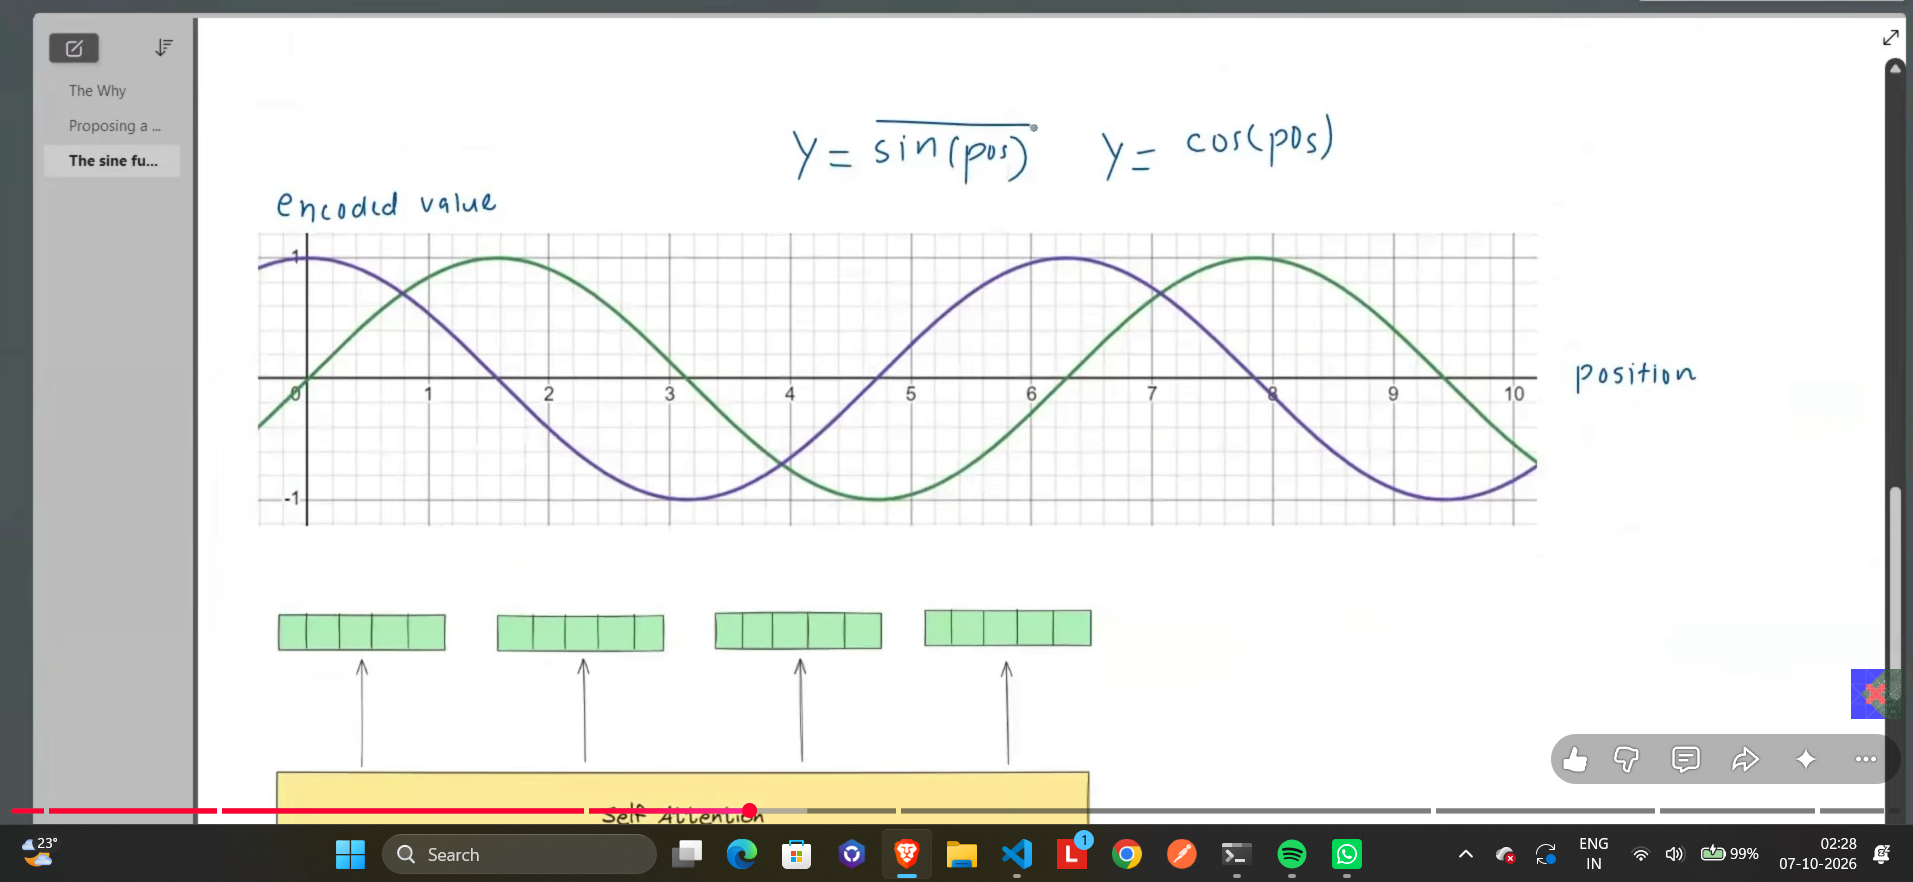

- ## In this also there is possibilty that the number will again be same so what we can do is that we will again add the same function function with the slight modification

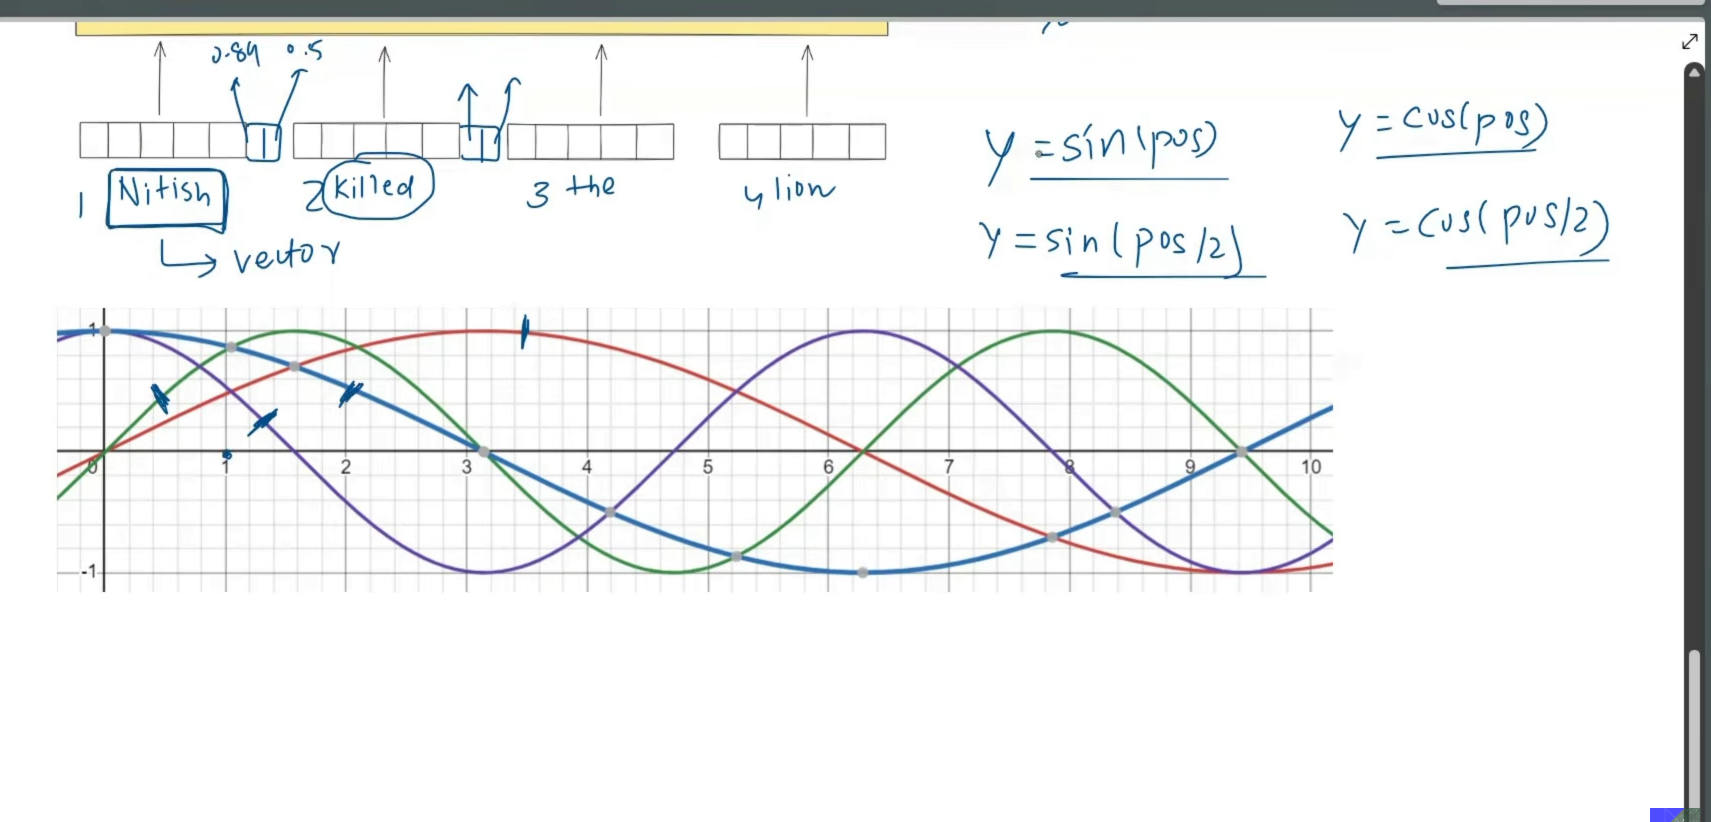

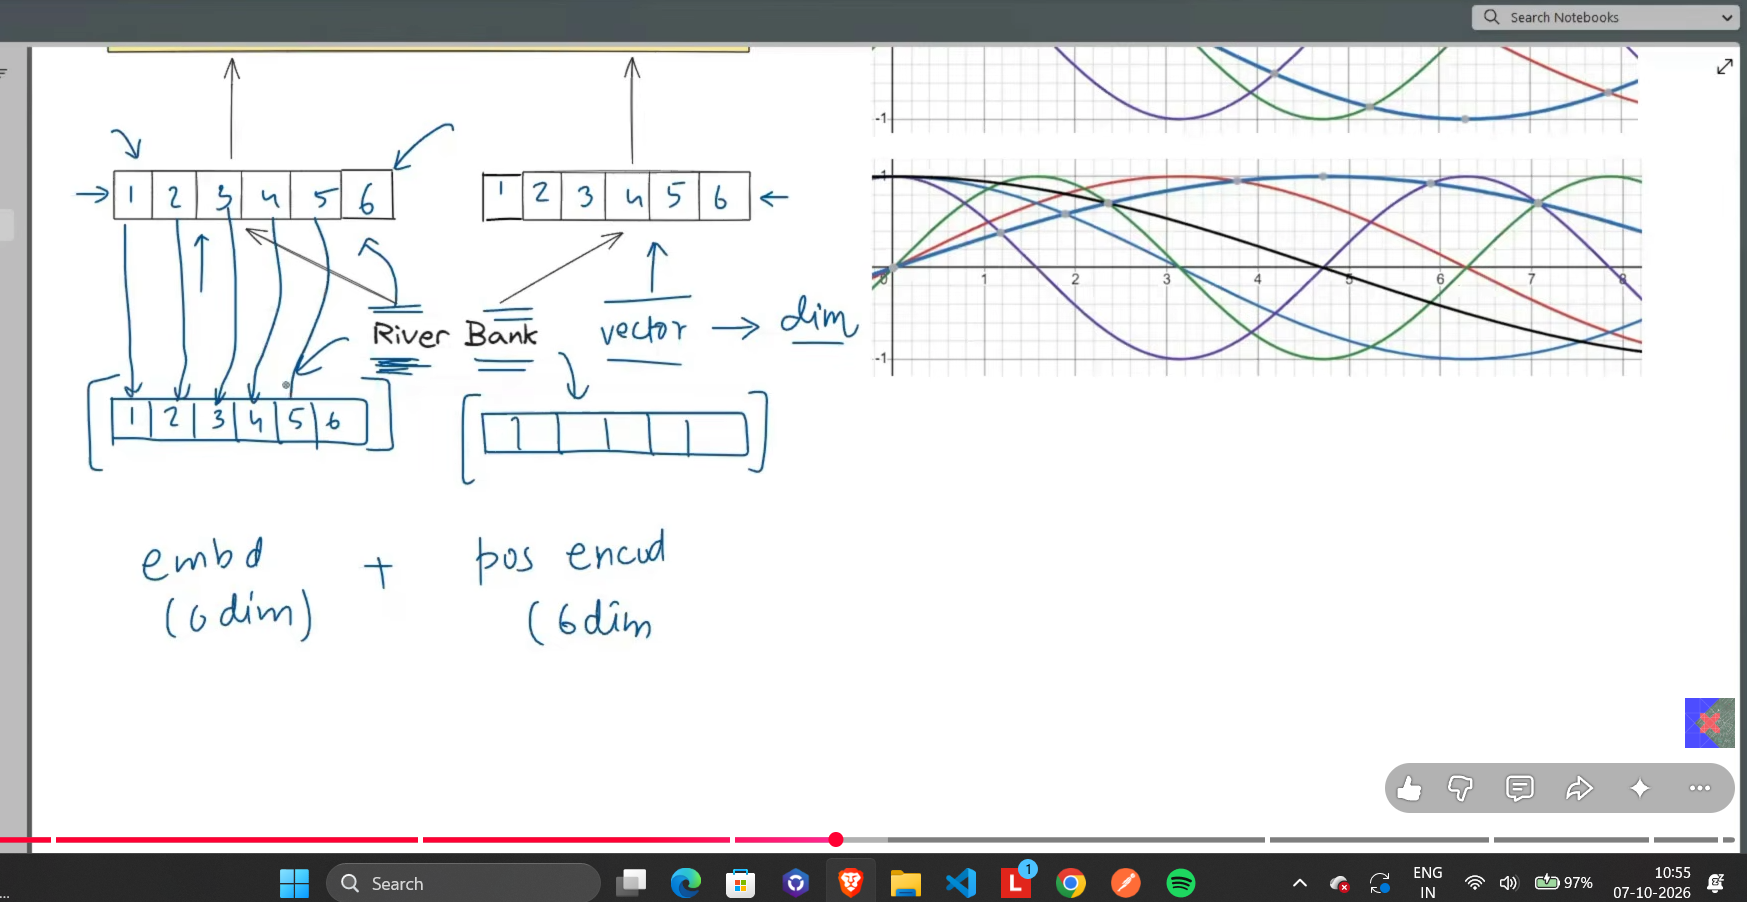

- ### Now for every word the positonal encoding will be the vector of the dimention same as of the embedding but we will add the positonal encond with the embeding vector as if we will add to the end then the diemention will increase by the factor of 2

##### Now the question is how we will change the frequency

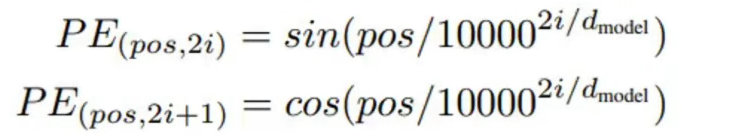

d model is dimentionality of the embedding \
i is from 0 to n/2-1

# Positional Encoding in Transformers: Complete Notes

## 1. Introduction
Transformers process tokens in parallel, lacking a built-in sense of order. To preserve sequence order, **Positional Encoding (PE)** is added to the input token embeddings[cite: 1].

## 2. Mathematical Formula
For a given position $pos$ and embedding dimension index $i$:
- Even dimensions ($2i$): 
  $$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$
- Odd dimensions ($2i+1$): 
  $$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

---

## 3. Step-by-Step Calculation Examples

### A. Position pos = 0
- **i = 0:**
  - $PE(0, 0) = \sin(0 / 10000^0) = 0$[cite: 1]
  - $PE(0, 1) = \cos(0 / 10000^0) = 1$[cite: 1]
- **i = 1:**
  - $PE(0, 2) = \sin(0 / 10000^{1/3}) = 0$[cite: 1]
  - $PE(0, 3) = \cos(0 / 10000^{1/3}) = 1$[cite: 1]
- **i = 2:**
  - $PE(0, 4) = \sin(0 / 10000^{2/3}) = 0$[cite: 1]
  - $PE(0, 5) = \cos(0 / 10000^{2/3}) = 1$[cite: 1]

### B. Position pos = 2
- **i = 0:**
  - $PE(2, 0) = \sin(1 / 10000^0) \approx 0.84$[cite: 1]
  - $PE(2, 1) = \cos(1 / 10000^0) = 0.54$[cite: 1]
- **i = 1:**
  - $PE(2, 2) = \sin(1 / 10000^{1/3}) \approx 0.04$[cite: 1]
  - $PE(2, 3) = \cos(1 / 10000^{1/3}) \approx 0.99$[cite: 1]
- **i = 2:**
  - $PE(2, 4) = \sin(1 / 10000^{2/3}) \approx 0.002$[cite: 1]
  - $PE(2, 5) = \cos(1 / 10000^{2/3}) \approx 0.999$[cite: 1]

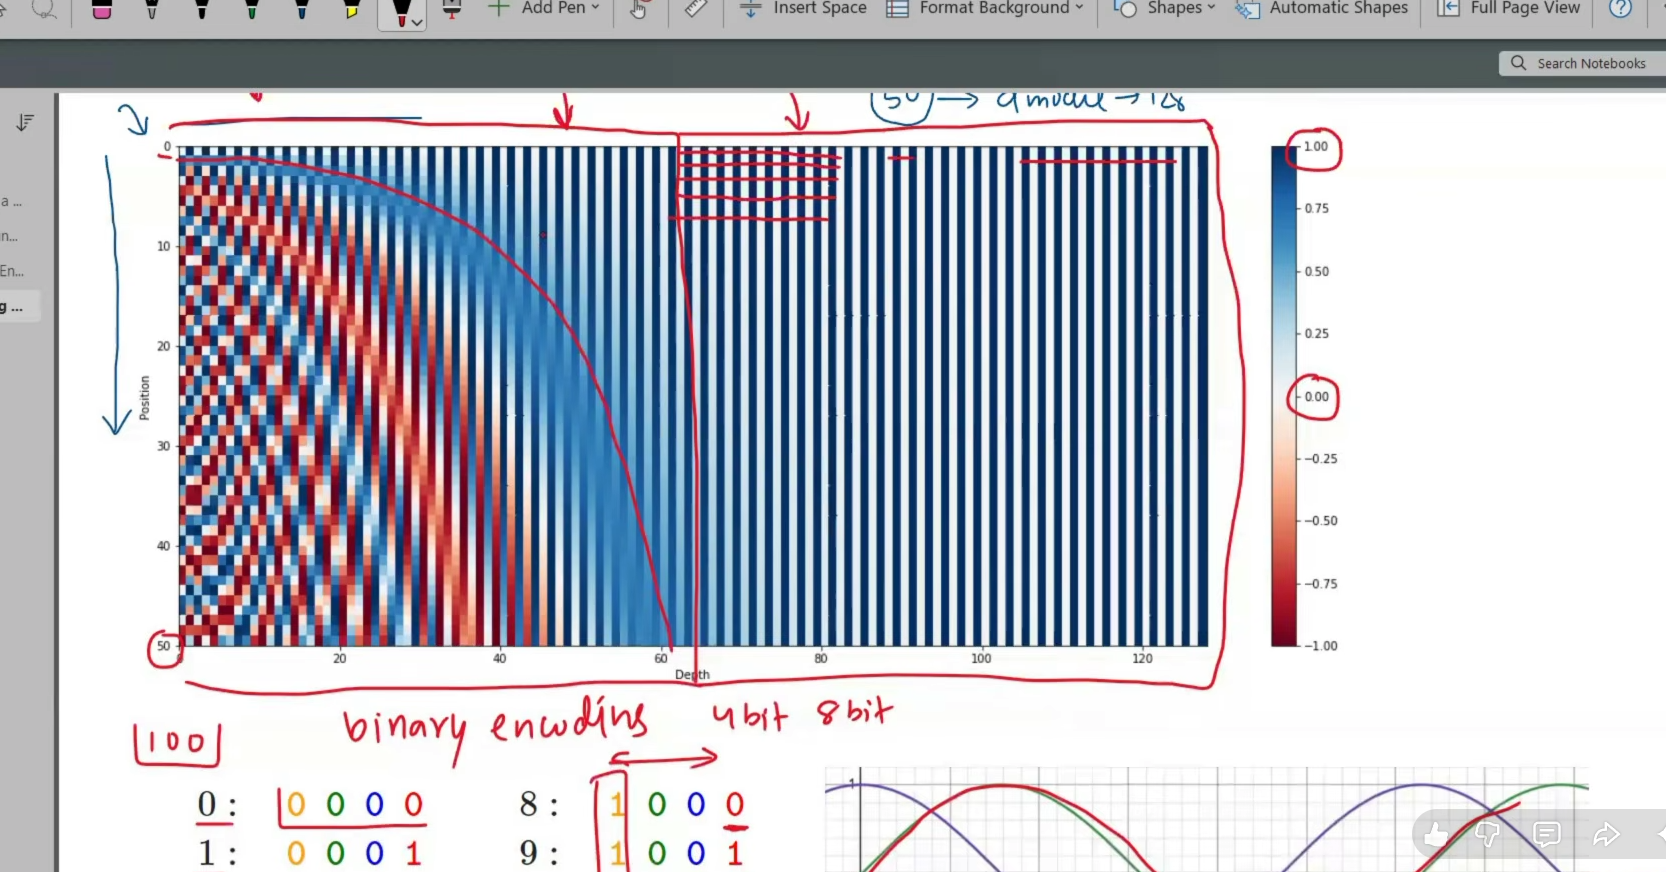 

https://blog.timodenk.com/linear-relationships-in-the-transformers-positional-encoding/

### Normalization 

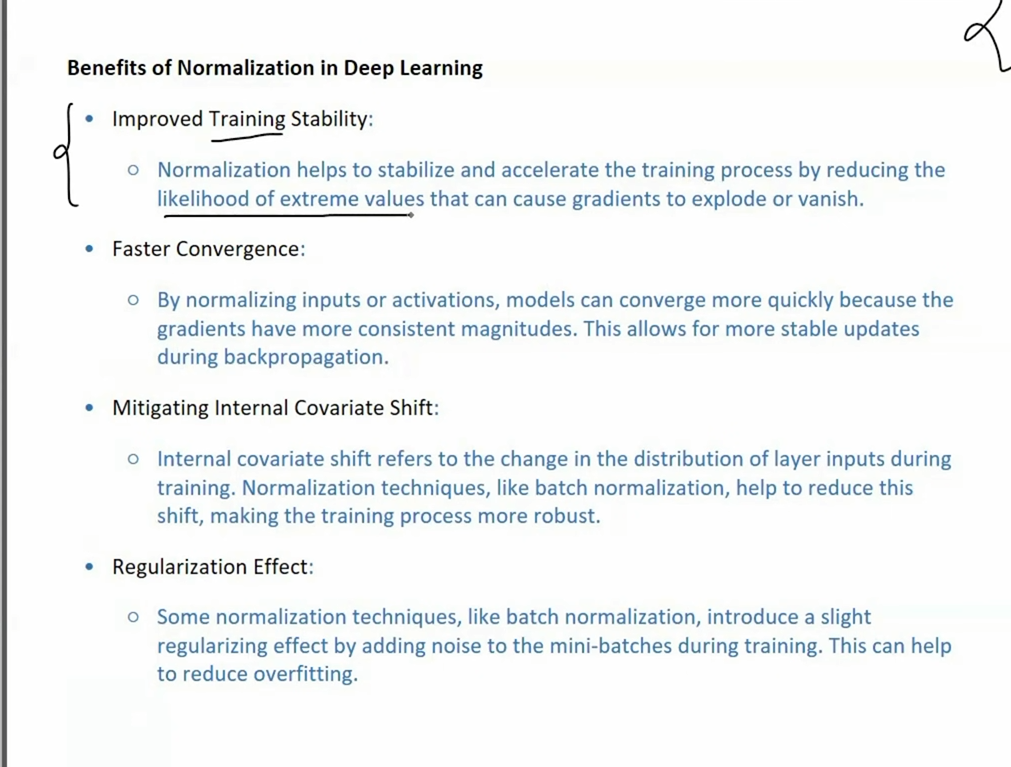

# Comprehensive Machine Learning Notes

## 1. Positional Encoding in Transformers

### Introduction
Transformers process tokens in parallel, lacking a built-in sense of order. To preserve sequence order, **Positional Encoding (PE)** is added to the input token embeddings.

### Mathematical Formula
For a given position $pos$ and embedding dimension index $i$:
- Even dimensions ($2i$): 
  $$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$
- Odd dimensions ($2i+1$): 
  $$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

### Step-by-Step Calculation Examples

#### A. Position pos = 0
- **i = 0:**
  - $PE(0, 0) = \sin(0 / 10000^0) = 0$
  - $PE(0, 1) = \cos(0 / 10000^0) = 1$
- **i = 1:**
  - $PE(0, 2) = \sin(0 / 10000^{1/3}) = 0$
  - $PE(0, 3) = \cos(0 / 10000^{1/3}) = 1$
- **i = 2:**
  - $PE(0, 4) = \sin(0 / 10000^{2/3}) = 0$
  - $PE(0, 5) = \cos(0 / 10000^{2/3}) = 1$

#### B. Position pos = 2
- **i = 0:**
  - $PE(2, 0) = \sin(1 / 10000^0) \approx 0.84$
  - $PE(2, 1) = \cos(1 / 10000^0) = 0.54$
- **i = 1:**
  - $PE(2, 2) = \sin(1 / 10000^{1/3}) \approx 0.04$
  - $PE(2, 3) = \cos(1 / 10000^{1/3}) \approx 0.99$
- **i = 2:**
  - $PE(2, 4) = \sin(1 / 10000^{2/3}) \approx 0.002$
  - $PE(2, 5) = \cos(1 / 10000^{2/3}) \approx 0.999$

---

## 2. Batch Normalization

### What is Batch Normalization?
**Batch Normalization (BatchNorm)** is a technique to make neural networks faster and more stable by normalizing the activations of a hidden layer across each mini-batch during training—centering them around a mean of zero and a standard deviation of one.

### The Problem: Internal Covariate Shift
As a deep neural network trains, earlier layer weights change constantly, causing the distribution of inputs to later layers to shift continuously (Internal Covariate Shift). This slows down training and requires small learning rates. BatchNorm solves this by stabilizing input distributions.

### How Batch Normalization Works (Step-by-Step)
For a given mini-batch $B$:
1. **Calculate Mini-Batch Mean ($\mu_B$):** Compute the mean of the current batch.
2. **Calculate Mini-Batch Variance ($\sigma_B^2$):** Compute the variance of the current batch.
3. **Normalize:** 
   $$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
4. **Scale and Shift ($\gamma$ and $\beta$):** 
   $$\text{Output}_i = \gamma \cdot \hat{x}_i + \beta$$
   *(Parameters $\gamma$ and $\beta$ are learnable parameters that allow the network to restore the representation capacity if needed).*

### Training vs. Inference Phase
- **During Training:** Mean and variance are computed dynamically per mini-batch, and a running average is updated.
- **During Inference:** The running mean and variance accumulated during training are used deterministically.

### Key Benefits
- Faster training with higher learning rates.
- Reduced sensitivity to weight initialization.
- Mild regularization effect (can reduce reliance on Dropout).
- Mitigates vanishing/exploding gradients.

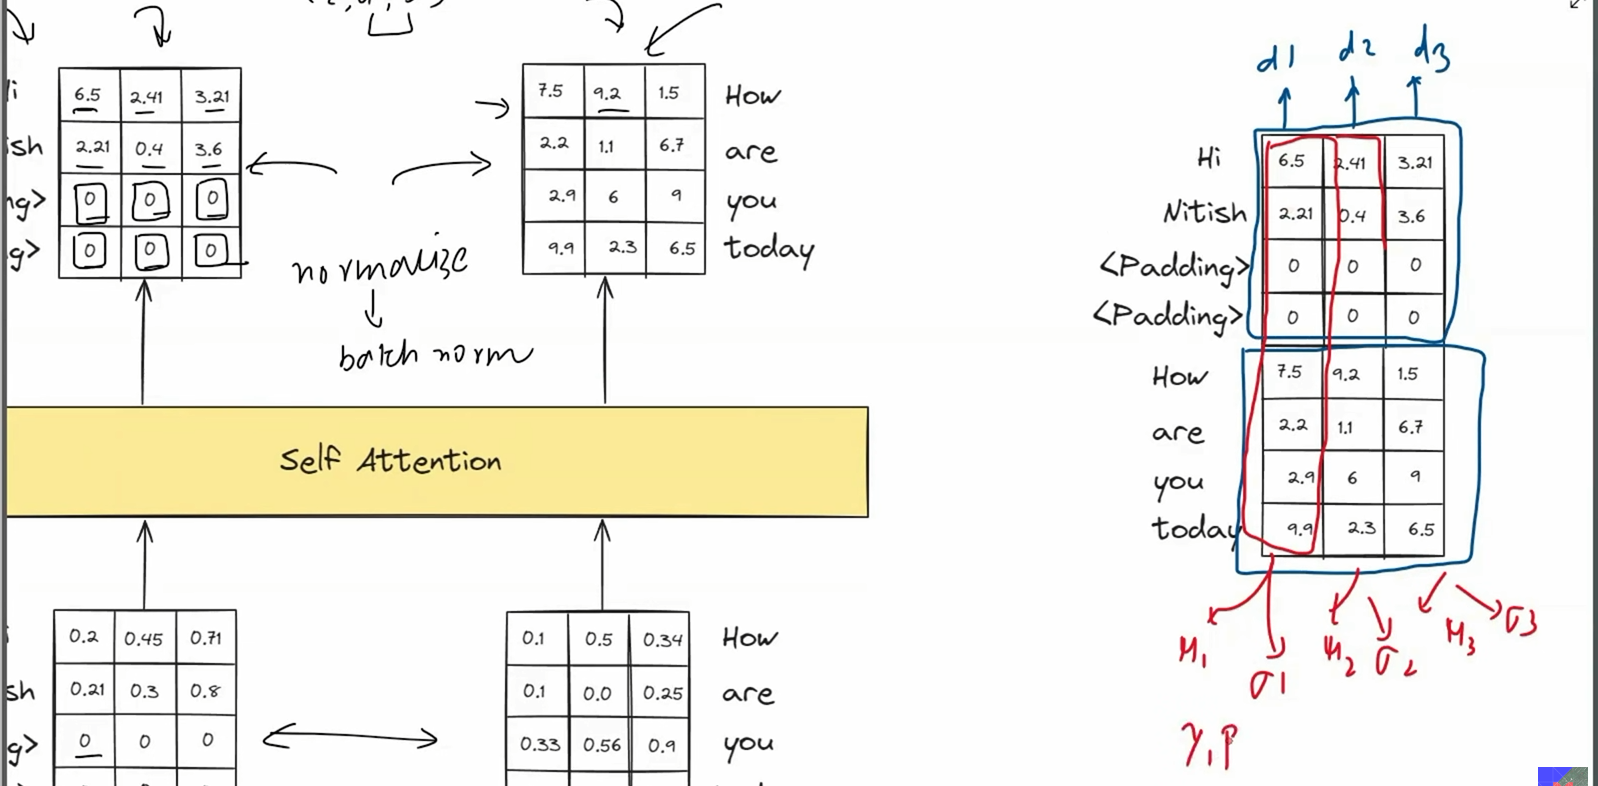

- ### The issue is with the number of zeroes in the data so as the longest sentence in the datamay be 100 words long so we cannot use the batch normalization in here as there will be too many unnceessary zeores in the whole matrix that will make the calculation useless

# Layer Normalization

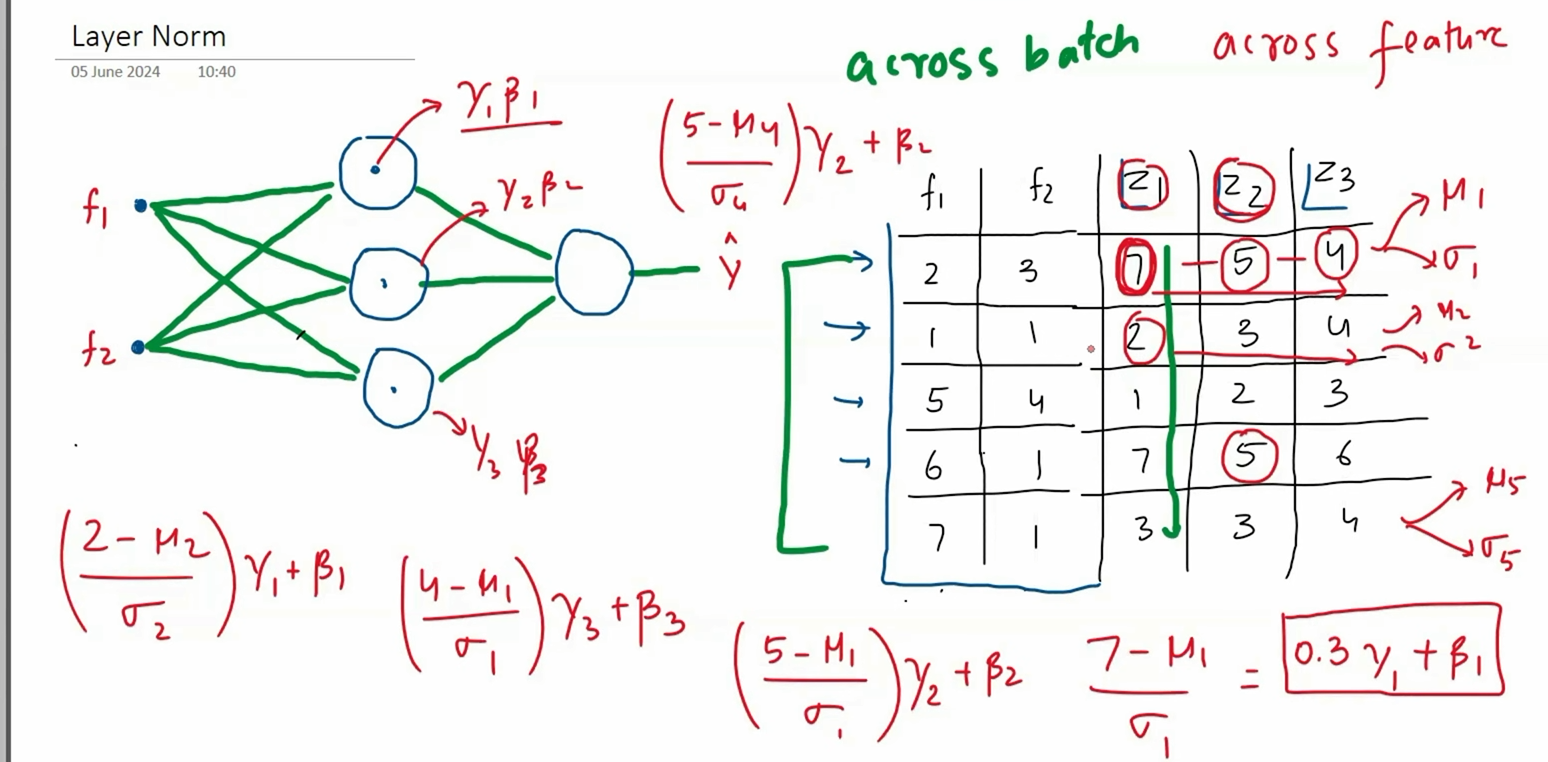

# In this we go across the layers like in the x  direction and apply the normalization

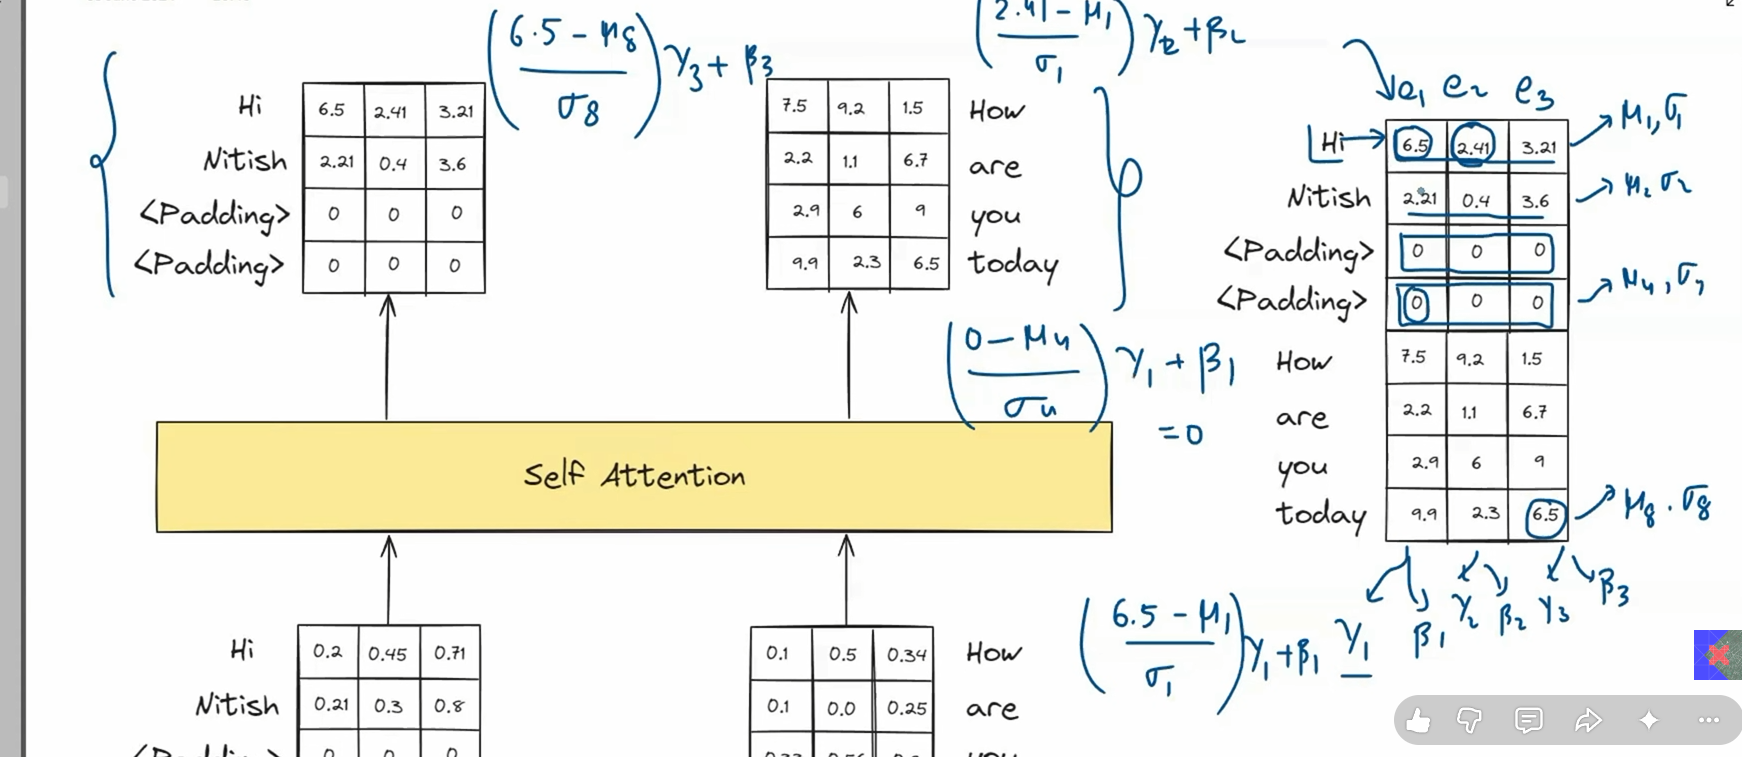

# so if we will do the layer normalization then the padding zeroes will not affect the other row or the column they will affect thmself and this is the benifit of the layer normalization 